## Import Library

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import numpy as np
import re


## Proporsi Demografi Penduduk

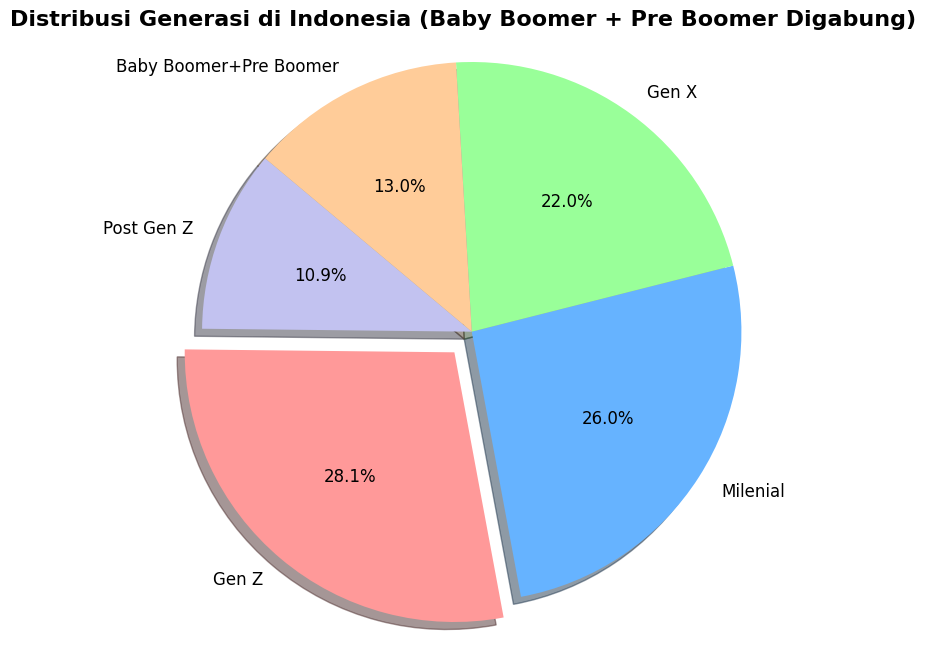

In [2]:
# Data awal (dari Excel kamu)
data = {
    'Generasi': ['Gen Z', 'Milenial', 'Gen X', 'Baby Boomer', 'Post Gen Z', 'Pre Boomer'],
    'Jumlah': [74.93, 69.38, 58.65, 31.01, 29.17, 3.55]  # Contoh, sesuaikan jika perlu
}
df = pd.DataFrame(data)

# Gabungkan "Baby Boomer" & "Pre Boomer"
df['Generasi'] = df['Generasi'].replace({'Baby Boomer': 'Baby Boomer+Pre Boomer', 'Pre Boomer': 'Baby Boomer+Pre Boomer'})

# Gabungkan jumlahnya
df_final = df.groupby('Generasi', as_index=False)['Jumlah'].sum()

# Urutkan generasi (opsional)
generation_order = ['Post Gen Z', 'Gen Z', 'Milenial', 'Gen X', 'Baby Boomer+Pre Boomer']
df_final['Generasi'] = pd.Categorical(df_final['Generasi'], categories=generation_order, ordered=True)
df_final = df_final.sort_values('Generasi')

# Pie Chart
labels = df_final['Generasi']
sizes = df_final['Jumlah']
colors = ['#C2C2F0', '#FF9999', '#66B3FF', '#99FF99', '#FFCC99']
explode = [0.1 if label == 'Gen Z' else 0 for label in labels]

plt.figure(figsize=(10, 8))
patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    shadow=True
)

# Perbesar teks
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(12)

plt.title('Distribusi Generasi di Indonesia (Baby Boomer + Pre Boomer Digabung)', fontsize=16, weight='bold')
plt.axis('equal')
plt.show()

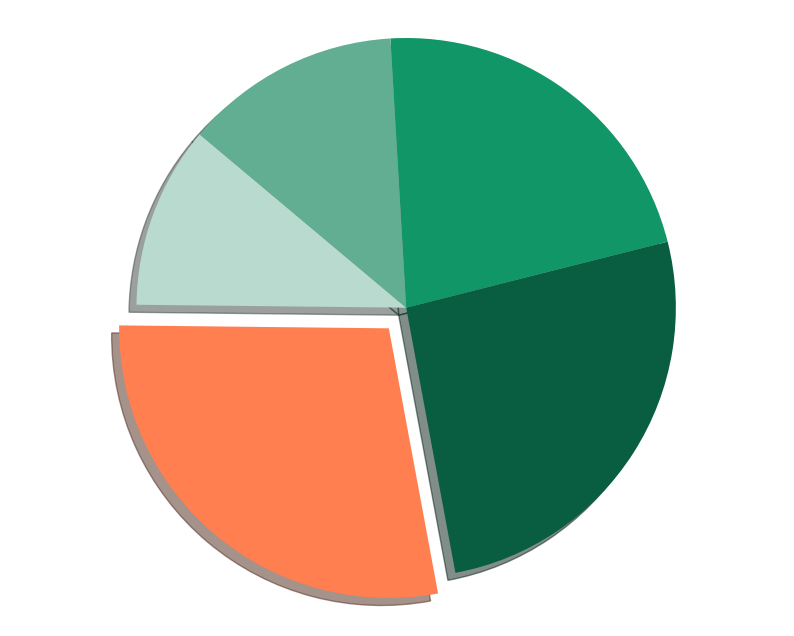

In [3]:
# Data awal (dari Excel kamu)
data = {
    'Generasi': ['Gen Z', 'Milenial', 'Gen X', 'Baby Boomer', 'Post Gen Z', 'Pre Boomer'],
    'Jumlah': [74.93, 69.38, 58.65, 31.01, 29.17, 3.55]  # Contoh, sesuaikan jika perlu
}
df = pd.DataFrame(data)

# Gabungkan "Baby Boomer" & "Pre Boomer"
df['Generasi'] = df['Generasi'].replace({'Baby Boomer': 'Baby Boomer+Pre Boomer', 'Pre Boomer': 'Baby Boomer+Pre Boomer'})

# Gabungkan jumlahnya
df_final = df.groupby('Generasi', as_index=False)['Jumlah'].sum()

# Urutkan generasi (opsional)
generation_order = ['Post Gen Z', 'Gen Z', 'Milenial', 'Gen X', 'Baby Boomer+Pre Boomer']
df_final['Generasi'] = pd.Categorical(df_final['Generasi'], categories=generation_order, ordered=True)
df_final = df_final.sort_values('Generasi')

# Pie Chart tanpa label
sizes = df_final['Jumlah']
colors = ['#b9dbcf', '#FF7F50', '#095d40', '#119668', '#62ae93']
explode = [0.1 if label == 'Gen Z' else 0 for label in df_final['Generasi']]

plt.figure(figsize=(10, 8))
plt.pie(
    sizes,
    colors=colors,
    startangle=140,
    explode=explode,
    shadow=True
)

plt.axis('equal')
plt.show()

## Proporsi Sektor Tenaga Kerja

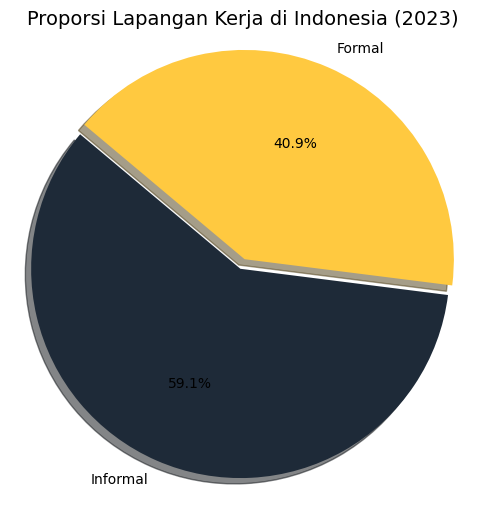

In [4]:
# Data
labels = ['Informal', 'Formal']
sizes = [59.11, 40.89]
colors = ['#1E2A38', '#FFC940']
explode = (0.05, 0)
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=140,
    autopct='%1.1f%%'
)
plt.title('Proporsi Lapangan Kerja di Indonesia (2023)', fontsize=14)
plt.axis('equal')
plt.show()

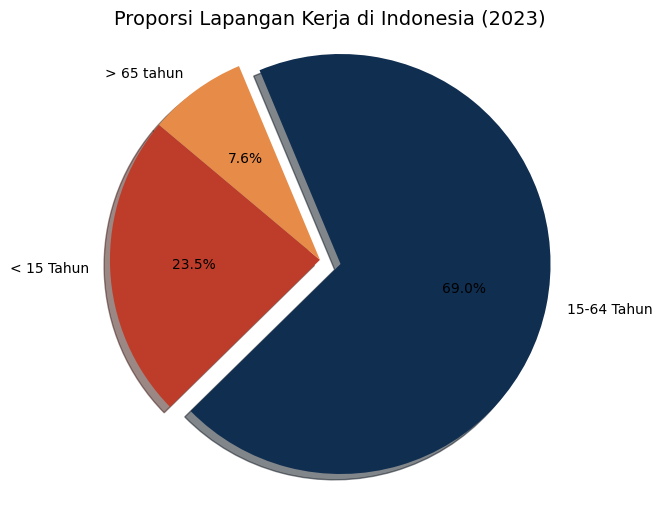

In [21]:
# Data
labels = ['< 15 Tahun', '15-64 Tahun', '> 65 tahun']
sizes = [66.72, 196.11, 21.58]
colors = ['#BE3D2A', '#102E50', '#E78B48' ]
explode = (0, 0.1, 0)
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=140,
    autopct='%1.1f%%'
)
plt.title('Proporsi Lapangan Kerja di Indonesia (2023)', fontsize=14)
plt.axis('equal')
plt.show()

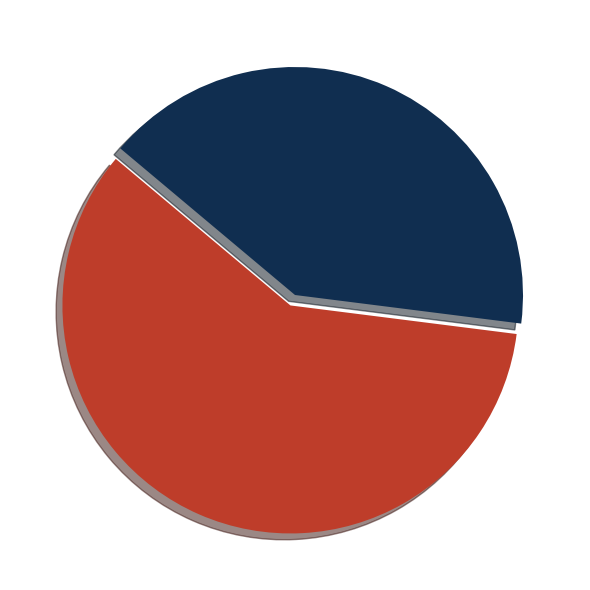

In [5]:
# Data
sizes = [59.11, 40.89]
colors = ['#BE3D2A', '#102E50']
explode = (0.05, 0)
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=140
)
plt.axis('off')
plt.tight_layout()
plt.show()

## Jumlah Angkatan Kerja

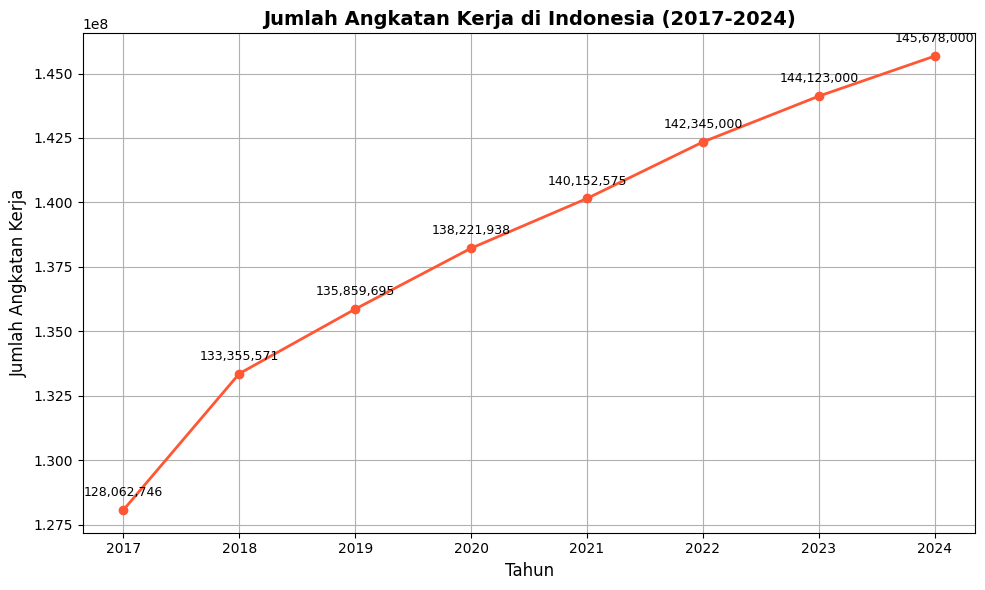

In [6]:
# Data dari Excel kamu
data = {
    'Tahun': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Jumlah Angkatan Kerja': [128062746, 133355571, 135859695, 138221938, 140152575, 142345000, 144123000, 145678000]
}
df_ak = pd.DataFrame(data)

# Warna garis bisa diubah di sini
line_color = '#FF5733'

plt.figure(figsize=(10, 6))
plt.plot(df_ak['Tahun'], df_ak['Jumlah Angkatan Kerja'], marker='o', color=line_color, linewidth=2)

# Menambahkan label di tiap titik
for i, txt in enumerate(df_ak['Jumlah Angkatan Kerja']):
    plt.annotate(f'{txt:,}', (df_ak['Tahun'][i], df_ak['Jumlah Angkatan Kerja'][i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title('Jumlah Angkatan Kerja di Indonesia (2017-2024)', fontsize=14, weight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Angkatan Kerja', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

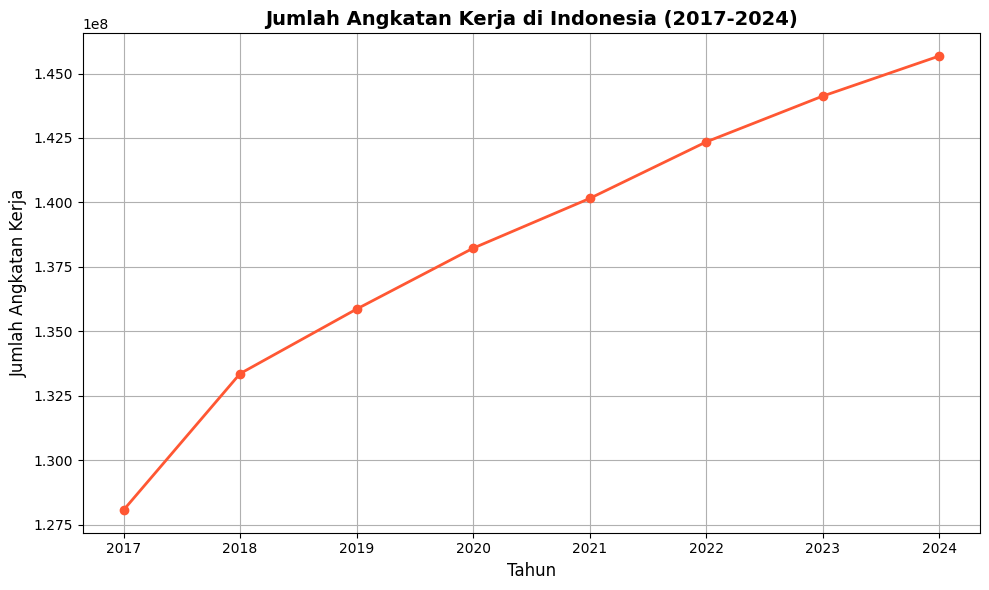

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df_ak['Tahun'], df_ak['Jumlah Angkatan Kerja'], marker='o', color=line_color, linewidth=2)

plt.title('Jumlah Angkatan Kerja di Indonesia (2017-2024)', fontsize=14, weight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Angkatan Kerja', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


## Peta Indonesia

In [8]:
gdf = gpd.read_file("C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp")
upah_df = pd.read_excel("C:/Uner/Organisasi/LKMM-TL/Data/Upah Rata - Rata Per Jam Pekerja Menurut Provinsi, 2023.xlsx")

In [9]:
upah_df["Upah Rata - Rata Per Jam Pekerja Menurut Provinsi (Rupiah/Jam)"].describe()

count       35.000000
mean     19643.885714
std       5581.216638
min      12933.000000
25%      16435.000000
50%      18413.000000
75%      20725.500000
max      42354.000000
Name: Upah Rata - Rata Per Jam Pekerja Menurut Provinsi (Rupiah/Jam), dtype: float64

In [10]:
print("Kolom di gdf:", gdf.columns.tolist())
print("Kolom di upah_df:", upah_df.columns.tolist())

Kolom di gdf: ['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
Kolom di upah_df: ['Provinsi', 'Upah Rata - Rata Per Jam Pekerja Menurut Provinsi (Rupiah/Jam)']


In [11]:
gdf["provinsi"] = gdf["NAME_1"].str.lower().str.strip()
upah_df["provinsi"] = upah_df["Provinsi"].str.lower().str.strip()

In [12]:
gdf["provinsi"] = gdf["NAME_1"].str.lower().str.strip()

In [13]:
def normalisasi_nama_provinsi(nama):
    if pd.isna(nama):
        return ""
    nama = nama.lower()
    nama = re.sub(r'[^a-z0-9 ]', '', nama)  # hilangkan karakter selain huruf, angka, spasi
    nama = re.sub(r'\s+', ' ', nama)        # ganti spasi ganda/tab/newline jadi 1 spasi
    return nama.strip()


In [14]:
gdf["provinsi"] = gdf["provinsi"].apply(normalisasi_nama_provinsi)
upah_df["provinsi"] = upah_df["provinsi"].apply(normalisasi_nama_provinsi)

In [15]:
merged = gdf.merge(upah_df, on="provinsi", how="left")

In [16]:
print("Provinsi tidak punya data Upah:")
print(merged[merged['Upah Rata - Rata Per Jam Pekerja Menurut Provinsi (Rupiah/Jam)'].isna()][['provinsi']])

Provinsi tidak punya data Upah:
           provinsi
2   bangka belitung
6      jakarta raya
16   kepulauan riau
33       yogyakarta


In [17]:
colors = [ '#FFC940', '#FF7F50']
cmap = LinearSegmentedColormap.from_list("custom", colors, N=256)

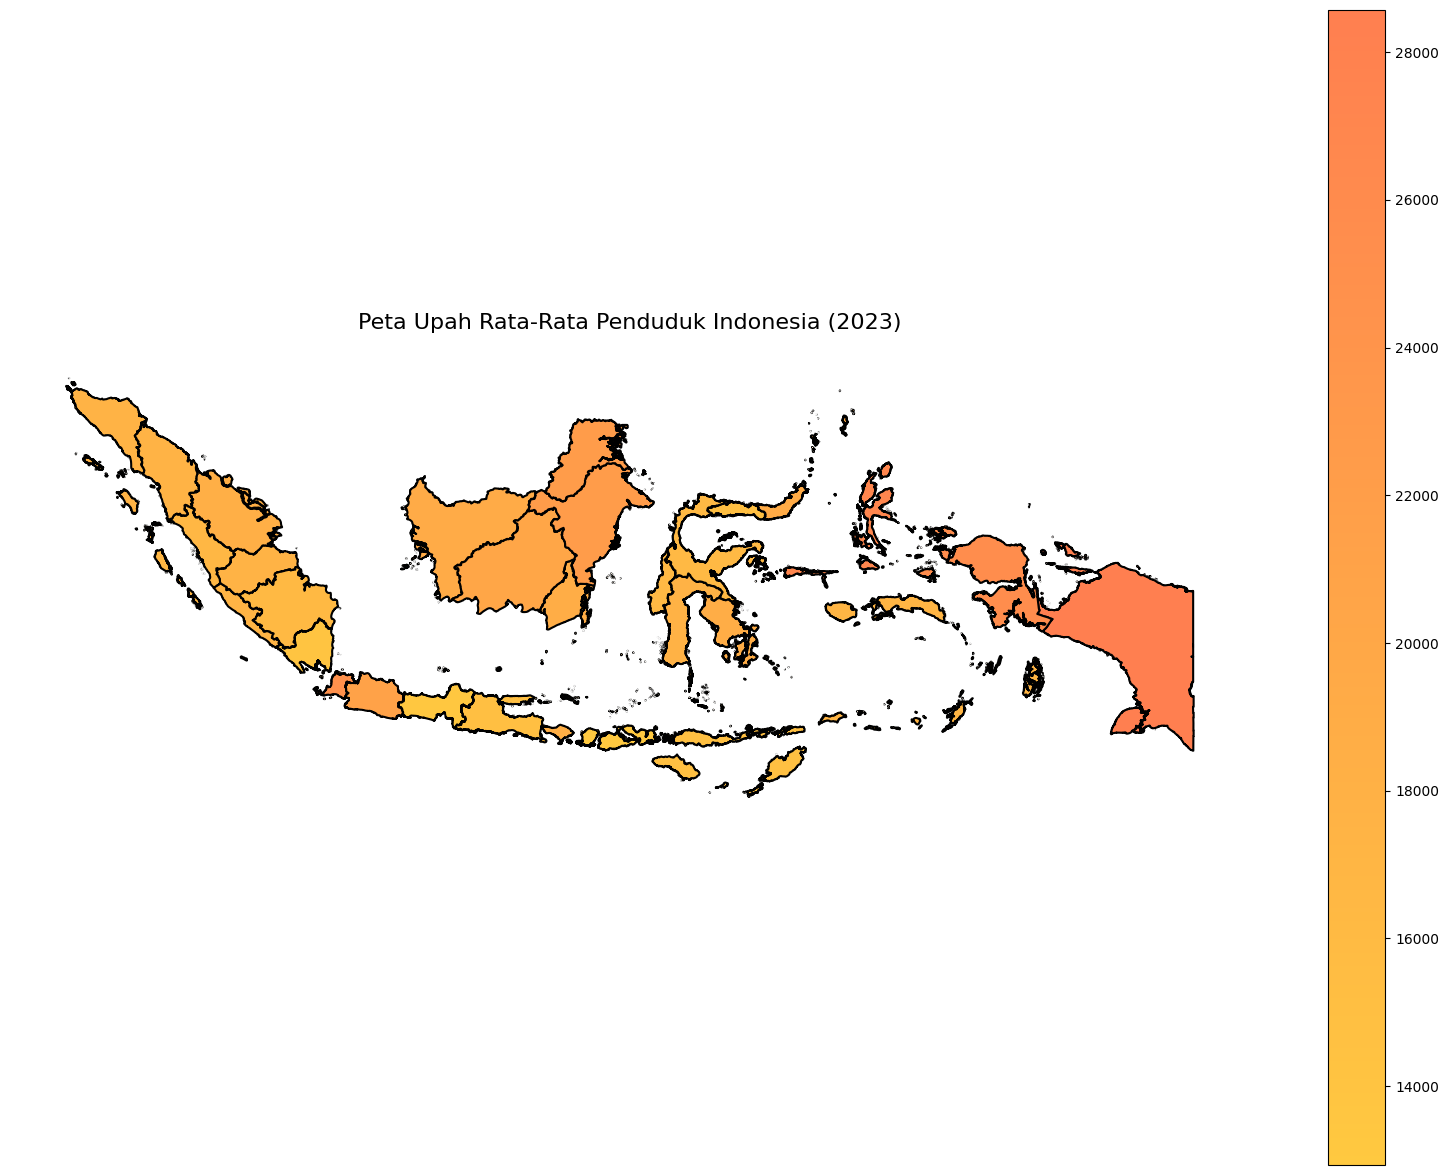

In [18]:
import matplotlib.pyplot as plt

# Parameter warna dan ketebalan garis batas
border_color = 'black'      # Warna garis batas antar provinsi
border_width = 1.5          # Ketebalan garis batas

fig, ax = plt.subplots(1, 1, figsize=(20, 15))  # Ukuran wajar untuk peta (120,100 terlalu besar)

merged.plot(
    column="Upah Rata - Rata Per Jam Pekerja Menurut Provinsi (Rupiah/Jam)",
    cmap=cmap,
    linewidth=border_width,
    edgecolor=border_color,
    legend=True,
    ax=ax
)

# Hiasan Peta
ax.set_title("Peta Upah Rata-Rata Penduduk Indonesia (2023)",
             fontdict={'fontsize': 16},
             pad=20)
ax.axis('off')

plt.show()
